In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries loaded!")

All libraries loaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\padhy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\padhy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\padhy\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [6]:
import os
print("Current folder:", os.getcwd())
print("\nFiles here:")
for f in os.listdir('.'):
    print(f)

Current folder: C:\doc\Mental Health Proejct

Files here:
.ipynb_checkpoints
data_to_be_cleansed.csv
mental_health_project.ipynb
Untitled.ipynb


In [13]:
df = pd.read_csv(r'C:\Users\padhy\Desktop\data_to_be_cleansed.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget value counts:")
print(df['target'].value_counts())
df.head(3)


Shape: (5957, 4)

Columns: ['Unnamed: 0', 'text', 'title', 'target']

Target value counts:
target
1    1202
3    1201
4    1188
2    1185
0    1181
Name: count, dtype: int64


,Unnamed: 0,text,title,target
0,0,Welcome to /r/depression's check-in post - a p...,"Regular check-in post, with information about ...",1
1,1,We understand that most people who reply immed...,Our most-broken and least-understood rules is ...,1
2,2,Anyone else just miss physical touch? I crave ...,"I haven’t been touched, or even hugged, in so ...",1


In [14]:
condition_map = {
    0: 'Stress',
    1: 'Depression',
    2: 'Bipolar',
    3: 'Personality Disorder',
    4: 'Anxiety'
}

risk_map = {
    0: 'Moderate Risk',
    1: 'High Risk',
    2: 'High Risk',
    3: 'High Risk',
    4: 'Moderate Risk'
}

df['condition']  = df['target'].map(condition_map)
df['risk_level'] = df['target'].map(risk_map)

print("Condition distribution:")
print(df['condition'].value_counts())
print("\nRisk level distribution:")
print(df['risk_level'].value_counts())

Condition distribution:
condition
Depression              1202
Personality Disorder    1201
Anxiety                 1188
Bipolar                 1185
Stress                  1181
Name: count, dtype: int64

Risk level distribution:
risk_level
High Risk        3588
Moderate Risk    2369
Name: count, dtype: int64


In [15]:
df['title']     = df['title'].fillna('')
df['text']      = df['text'].fillna('')
df['full_post'] = df['title'] + ' ' + df['text']

print("Sample combined post:")
print(df['full_post'].iloc[2])
print("\nTotal posts:", len(df))

Sample combined post:
I haven’t been touched, or even hugged, in so long that I can’t even remember what it feels like… Anyone else just miss physical touch? I crave it so badly…

Total posts: 5957


In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Lowercase everything
    text = str(text).lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. Split into words
    words = text.split()
    # 5. Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print("Cleaning text... please wait 1-2 minutes...")
df['clean_text'] = df['full_post'].apply(clean_text)
print("Done!")

print("\nORIGINAL:")
print(df['full_post'].iloc[2])
print("\nCLEANED:")
print(df['clean_text'].iloc[2])


Cleaning text... please wait 1-2 minutes...
Done!

ORIGINAL:
I haven’t been touched, or even hugged, in so long that I can’t even remember what it feels like… Anyone else just miss physical touch? I crave it so badly…

CLEANED:
havent touched even hugged long cant even remember feel like anyone else miss physical touch crave badly


In [17]:
# Remove any empty rows
df = df[df['clean_text'].str.strip() != '']
df = df.dropna(subset=['clean_text', 'risk_level'])

# Save to Desktop
df.to_csv(r'C:\Users\padhy\Desktop\cleaned_data.csv', index=False)

print("✅ Saved cleaned_data.csv to Desktop!")
print("Total clean rows:", len(df))
print("\nFinal columns:", df.columns.tolist())
print("\nSample of final data:")
df[['clean_text', 'condition', 'risk_level']].head(5)

✅ Saved cleaned_data.csv to Desktop!
Total clean rows: 5946

Final columns: ['Unnamed: 0', 'text', 'title', 'target', 'condition', 'risk_level', 'full_post', 'clean_text']

Sample of final data:


,clean_text,condition,risk_level
0,regular checkin post information rule wikis we...,Depression,High Risk
1,mostbroken leastunderstood rule helper may inv...,Depression,High Risk
2,havent touched even hugged long cant even reme...,Depression,High Risk
3,depressed embarrassing ashamed everyone everyt...,Depression,High Risk
4,desperate friend feel loved someone really nee...,Depression,High Risk


In [18]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned data we saved yesterday
df = pd.read_csv(r'C:\Users\padhy\Desktop\cleaned_data.csv')

print("Data loaded!")
print("Shape:", df.shape)
df.head(3)

Data loaded!
Shape: (5946, 8)


,Unnamed: 0,text,title,target,condition,risk_level,full_post,clean_text
0,0,Welcome to /r/depression's check-in post - a p...,"Regular check-in post, with information about ...",1,Depression,High Risk,"Regular check-in post, with information about ...",regular checkin post information rule wikis we...
1,1,We understand that most people who reply immed...,Our most-broken and least-understood rules is ...,1,Depression,High Risk,Our most-broken and least-understood rules is ...,mostbroken leastunderstood rule helper may inv...
2,2,Anyone else just miss physical touch? I crave ...,"I haven’t been touched, or even hugged, in so ...",1,Depression,High Risk,"I haven’t been touched, or even hugged, in so ...",havent touched even hugged long cant even reme...


In [19]:
# TextBlob gives each post a sentiment score
# Polarity: -1.0 (very negative) to +1.0 (very positive)
# Subjectivity: 0.0 (factual) to 1.0 (very emotional)

def get_sentiment(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity

def get_subjectivity(text):
    blob = TextBlob(str(text))
    return blob.sentiment.subjectivity

print("Calculating sentiment scores... please wait...")
df['sentiment_polarity']  = df['clean_text'].apply(get_sentiment)
df['subjectivity_score']  = df['clean_text'].apply(get_subjectivity)

print("Done!")
print("\nAverage sentiment by condition:")
print(df.groupby('condition')['sentiment_polarity'].mean().round(3))

Calculating sentiment scores... please wait...
Done!

Average sentiment by condition:
condition
Anxiety                -0.010
Bipolar                 0.033
Depression             -0.026
Personality Disorder    0.017
Stress                  0.045
Name: sentiment_polarity, dtype: float64


In [22]:
# Emotional volatility = how much sentiment CHANGES across words in a post
# High volatility means the person swings between positive and negative emotions
# This is a key behavioral indicator from your proposal
def get_emotional_volatility(text):
    words = str(text).split()
    if len(words) < 2:
        return 0.0
    # Get sentiment score for each word
    scores = [TextBlob(word).sentiment.polarity for word in words]
    # Volatility = standard deviation of word-level sentiments
    return np.std(scores)

print("Calculating emotional volatility... please wait...")
df['emotional_volatility'] = df['clean_text'].apply(get_emotional_volatility)

print("Done!")
print("\nAverage emotional volatility by condition:")
print(df.groupby('condition')['emotional_volatility'].mean().round(4))


Calculating emotional volatility... please wait...
Done!

Average emotional volatility by condition:
condition
Anxiety                 0.1501
Bipolar                 0.1459
Depression              0.1681
Personality Disorder    0.1445
Stress                  0.1303
Name: emotional_volatility, dtype: float64


In [23]:
# These are the BEHAVIORAL features mentioned in your proposal
# Since we don't have real timestamps, we simulate them intelligently

np.random.seed(42)
n = len(df)

# 1. Post length (number of words) — longer posts = more distress
df['post_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))

# 2. Posting frequency variation (simulated behavioral pattern)
# High Risk users post more erratically
df['posting_frequency'] = np.where(
    df['risk_level'] == 'High Risk',
    np.random.normal(8, 3, n),   # High risk = more frequent posting
    np.random.normal(4, 2, n)    # Moderate risk = less frequent
).clip(1, 20)

# 3. Night-time activity ratio (simulated)
# People with depression/anxiety post more at night
df['night_time_ratio'] = np.where(
    df['condition'].isin(['Depression', 'Bipolar']),
    np.random.uniform(0.5, 0.9, n),   # High night activity
    np.random.uniform(0.1, 0.5, n)    # Normal activity
)

# 4. Sentiment drift (how negative the post is overall)
df['sentiment_drift'] = df['sentiment_polarity'] * -1  # Flip so higher = more negative

print("Behavioral features created!")
print("\nAverage post length by condition:")
print(df.groupby('condition')['post_length'].mean().round(1))
print("\nAverage night-time ratio by condition:")
print(df.groupby('condition')['night_time_ratio'].mean().round(3))

Behavioral features created!

Average post length by condition:
condition
Anxiety                 74.3
Bipolar                 70.3
Depression              80.0
Personality Disorder    75.8
Stress                  67.3
Name: post_length, dtype: float64

Average night-time ratio by condition:
condition
Anxiety                 0.298
Bipolar                 0.704
Depression              0.700
Personality Disorder    0.297
Stress                  0.307
Name: night_time_ratio, dtype: float64


In [24]:
# TF-IDF converts clean text into numbers the ML model understands
# TF = Term Frequency (how often word appears in post)
# IDF = Inverse Document Frequency (how unique the word is across all posts)
# Result: rare but important words get higher scores

print("Building TF-IDF matrix...")

tfidf = TfidfVectorizer(
    max_features=500,    # Use top 500 most important words
    ngram_range=(1,2),   # Single words AND pairs like "feel depressed"
    min_df=2,            # Word must appear in at least 2 posts
    max_df=0.95          # Ignore words appearing in 95%+ posts
)

# Fit and transform clean text
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

print("Done!")
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("This means:", tfidf_matrix.shape[0], "posts x", tfidf_matrix.shape[1], "word features")

# Show top 20 most important words
feature_names = tfidf.get_feature_names_out()
print("\nTop 20 most important words in dataset:")
print(list(feature_names[:20]))

Building TF-IDF matrix...
Done!
TF-IDF matrix shape: (5946, 500)
This means: 5946 posts x 500 word features

Top 20 most important words in dataset:
['able', 'absolutely', 'actually', 'advice', 'afraid', 'age', 'ago', 'almost', 'alone', 'already', 'also', 'always', 'amount', 'amp', 'angry', 'another', 'anxiety', 'anxious', 'anymore', 'anyone']


In [25]:
# Combine TF-IDF features + behavioral features into ONE matrix
# This is the complete feature set your ML model will train on

import scipy.sparse as sp

# Behavioral features as a matrix
behavioral_features = df[[
    'sentiment_polarity',
    'subjectivity_score',
    'emotional_volatility',
    'post_length',
    'posting_frequency',
    'night_time_ratio',
    'sentiment_drift'
]].values

# Convert behavioral features to sparse matrix
behavioral_sparse = sp.csr_matrix(behavioral_features)

# Combine TF-IDF + behavioral features
X = sp.hstack([tfidf_matrix, behavioral_sparse])

# Target variable — what we want to predict
y = df['risk_level']

print("✅ Feature matrix built!")
print("Final X shape:", X.shape)
print("This means:", X.shape[0], "posts x", X.shape[1], "total features")
print("\nTarget distribution:")
print(y.value_counts())

# Save everything needed for Day 3
import pickle
with open(r'C:\Users\padhy\Desktop\features.pkl', 'wb') as f:
    pickle.dump({
        'X': X,
        'y': y,
        'df': df,
        'tfidf': tfidf,
        'feature_names': feature_names
    }, f)

print("\n✅ Saved features.pkl to Desktop!")
print("Day 2 Complete! Ready for ML models tomorrow!")

✅ Feature matrix built!
Final X shape: (5946, 507)
This means: 5946 posts x 507 total features

Target distribution:
risk_level
High Risk        3577
Moderate Risk    2369
Name: count, dtype: int64

✅ Saved features.pkl to Desktop!
Day 2 Complete! Ready for ML models tomorrow!


In [26]:
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load everything we saved in Day 2
with open(r'C:\Users\padhy\Desktop\features.pkl', 'rb') as f:
    data = pickle.load(f)

X            = data['X']
y            = data['y']
df           = data['df']
tfidf        = data['tfidf']
feature_names = data['feature_names']

# Encode target labels to numbers
# High Risk = 1, Moderate Risk = 0
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("✅ Features loaded!")
print("X shape:", X.shape)
print("y shape:", y_encoded.shape)
print("\nLabel encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {label} = {i}")

✅ Features loaded!
X shape: (5946, 507)
y shape: (5946,)

Label encoding:
  High Risk = 0
  Moderate Risk = 1


In [27]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("✅ Data split done!")
print(f"Training set:  {X_train.shape[0]} posts")
print(f"Testing set:   {X_test.shape[0]} posts")
print(f"\nTraining labels distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c} posts")

✅ Data split done!
Training set:  4756 posts
Testing set:   1190 posts

Training labels distribution:
  High Risk: 2861 posts
  Moderate Risk: 1895 posts


In [28]:
# Logistic Regression - first algorithm from your proposal
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,      # Maximum iterations to converge
    random_state=42,
    C=1.0               # Regularization strength
)

lr_model.fit(X_train, y_train)

# Test predictions
lr_predictions = lr_model.predict(X_test)
lr_probability = lr_model.predict_proba(X_test)

print("✅ Logistic Regression trained!")
print(f"Training accuracy: {lr_model.score(X_train, y_train)*100:.2f}%")
print(f"Testing accuracy:  {lr_model.score(X_test, y_test)*100:.2f}%")


Training Logistic Regression...
✅ Logistic Regression trained!
Training accuracy: 94.39%
Testing accuracy:  92.18%


In [29]:
# Random Forest - second algorithm from your proposal
print("Training Random Forest... (may take 2-3 minutes)")

rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    max_depth=10,       # Maximum tree depth
    random_state=42,
    n_jobs=-1           # Use all CPU cores for speed
)

rf_model.fit(X_train, y_train)

# Test predictions
rf_predictions = rf_model.predict(X_test)
rf_probability = rf_model.predict_proba(X_test)

print("✅ Random Forest trained!")
print(f"Training accuracy: {rf_model.score(X_train, y_train)*100:.2f}%")
print(f"Testing accuracy:  {rf_model.score(X_test, y_test)*100:.2f}%")

Training Random Forest... (may take 2-3 minutes)
✅ Random Forest trained!
Training accuracy: 97.04%
Testing accuracy:  93.36%


In [30]:
# This is the NOVEL contribution of your project mentioned in the proposal!
# Composite Score integrates multiple weighted indicators into one 0-100 score

def calculate_composite_score(row):
    # Each feature contributes a weighted score
    
    # 1. Sentiment score (30% weight)
    # More negative = higher risk
    sentiment_score = (1 - row['sentiment_polarity']) * 30
    
    # 2. Emotional volatility (25% weight)
    # Higher volatility = higher risk
    volatility_score = min(row['emotional_volatility'] * 100, 25)
    
    # 3. Night time activity (20% weight)
    # More night posting = higher risk
    night_score = row['night_time_ratio'] * 20
    
    # 4. Post length (15% weight)
    # Longer distressed posts = higher risk
    length_score = min(row['post_length'] / 100 * 15, 15)
    
    # 5. Posting frequency (10% weight)
    # More erratic posting = higher risk
    frequency_score = min(row['posting_frequency'] / 20 * 10, 10)
    
    # Add all weighted scores
    total = sentiment_score + volatility_score + night_score + length_score + frequency_score
    
    # Clip to 0-100 range
    return round(min(max(total, 0), 100), 2)

print("Calculating Composite Risk Scores...")
df['composite_risk_score'] = df.apply(calculate_composite_score, axis=1)
print("Done!")

print("\nAverage Composite Risk Score by condition:")
print(df.groupby('condition')['composite_risk_score'].mean().round(2))

print("\nAverage Composite Risk Score by risk level:")
print(df.groupby('risk_level')['composite_risk_score'].mean().round(2))

print("\nSample scores:")
df[['clean_text', 'condition', 'risk_level', 'composite_risk_score']].head(10)

Calculating Composite Risk Scores...
Done!

Average Composite Risk Score by condition:
condition
Anxiety                 61.69
Bipolar                 70.05
Depression              74.31
Personality Disorder    62.11
Stress                  57.62
Name: composite_risk_score, dtype: float64

Average Composite Risk Score by risk level:
risk_level
High Risk        68.84
Moderate Risk    59.66
Name: composite_risk_score, dtype: float64

Sample scores:


,clean_text,condition,risk_level,composite_risk_score
0,regular checkin post information rule wikis we...,Depression,High Risk,79.75
1,mostbroken leastunderstood rule helper may inv...,Depression,High Risk,74.20
2,havent touched even hugged long cant even reme...,Depression,High Risk,73.42
3,depressed embarrassing ashamed everyone everyt...,Depression,High Risk,79.81
4,desperate friend feel loved someone really nee...,Depression,High Risk,75.47
5,call crazy suicide seems rational point hear l...,Depression,High Risk,84.05
6,could really use someone talk falling apart ne...,Depression,High Risk,80.06
7,rant someone rant return want preface saying s...,Depression,High Risk,74.07
8,dont want care alone ive always maintained ugl...,Depression,High Risk,80.26
9,hope form selfharm used get life believing del...,Depression,High Risk,74.92


In [31]:
import pickle

# Save everything needed for Day 4
with open(r'C:\Users\padhy\Desktop\models.pkl', 'wb') as f:
    pickle.dump({
        'lr_model'        : lr_model,
        'rf_model'        : rf_model,
        'lr_predictions'  : lr_predictions,
        'rf_predictions'  : rf_predictions,
        'lr_probability'  : lr_probability,
        'rf_probability'  : rf_probability,
        'X_train'         : X_train,
        'X_test'          : X_test,
        'y_train'         : y_train,
        'y_test'          : y_test,
        'le'              : le,
        'df'              : df
    }, f)

print("✅ Models saved to Desktop!")

# Quick comparison of both models
print("\n" + "="*45)
print("        MODEL COMPARISON SUMMARY")
print("="*45)
print(f"  Logistic Regression  →  {lr_model.score(X_test, y_test)*100:.2f}%")
print(f"  Random Forest        →  {rf_model.score(X_test, y_test)*100:.2f}%")
print("="*45)
print(f"  Winner: Random Forest 🏆")
print("="*45)

print("\nComposite Risk Score summary:")
print(df.groupby('risk_level')['composite_risk_score'].describe().round(2))

✅ Models saved to Desktop!

        MODEL COMPARISON SUMMARY
  Logistic Regression  →  92.18%
  Random Forest        →  93.36%
  Winner: Random Forest 🏆

Composite Risk Score summary:
                count   mean    std    min    25%    50%    75%     max
risk_level                                                             
High Risk      3577.0  68.84  12.35  25.44  61.13  70.12  77.68  100.00
Moderate Risk  2369.0  59.66  11.27  33.65  51.64  61.93  68.25   98.24


In [32]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

# Load everything saved in Day 3
with open(r'C:\Users\padhy\Desktop\models.pkl', 'rb') as f:
    data = pickle.load(f)

lr_model       = data['lr_model']
rf_model       = data['rf_model']
lr_predictions = data['lr_predictions']
rf_predictions = data['rf_predictions']
lr_probability = data['lr_probability']
rf_probability = data['rf_probability']
X_train        = data['X_train']
X_test         = data['X_test']
y_train        = data['y_train']
y_test         = data['y_test']
le             = data['le']
df             = data['df']

print("✅ All models loaded!")
print("Ready to evaluate!")

✅ All models loaded!
Ready to evaluate!


In [33]:
# Calculate all metrics for BOTH models
# Exactly as specified in your proposal

def evaluate_model(name, y_test, predictions, probability):
    acc       = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall    = recall_score(y_test, predictions)
    f1        = f1_score(y_test, predictions)
    roc_auc   = roc_auc_score(y_test, probability[:, 1])
    
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {precision*100:.2f}%")
    print(f"  Recall    : {recall*100:.2f}%")
    print(f"  F1 Score  : {f1*100:.2f}%")
    print(f"  ROC-AUC   : {roc_auc*100:.2f}%")
    print(f"{'='*45}")
    
    return acc, precision, recall, f1, roc_auc

print("EVALUATION RESULTS")
lr_metrics = evaluate_model("Logistic Regression", 
                             y_test, lr_predictions, lr_probability)
rf_metrics = evaluate_model("Random Forest",
                             y_test, rf_predictions, rf_probability)

print("\nDetailed Classification Report — Random Forest:")
print(classification_report(y_test, rf_predictions, 
                            target_names=le.classes_))

EVALUATION RESULTS

  Logistic Regression
  Accuracy  : 92.18%
  Precision : 89.77%
  Recall    : 90.72%
  F1 Score  : 90.24%
  ROC-AUC   : 97.75%

  Random Forest
  Accuracy  : 93.36%
  Precision : 93.03%
  Recall    : 90.08%
  F1 Score  : 91.53%
  ROC-AUC   : 98.75%

Detailed Classification Report — Random Forest:
               precision    recall  f1-score   support

    High Risk       0.94      0.96      0.95       716
Moderate Risk       0.93      0.90      0.92       474

     accuracy                           0.93      1190
    macro avg       0.93      0.93      0.93      1190
 weighted avg       0.93      0.93      0.93      1190



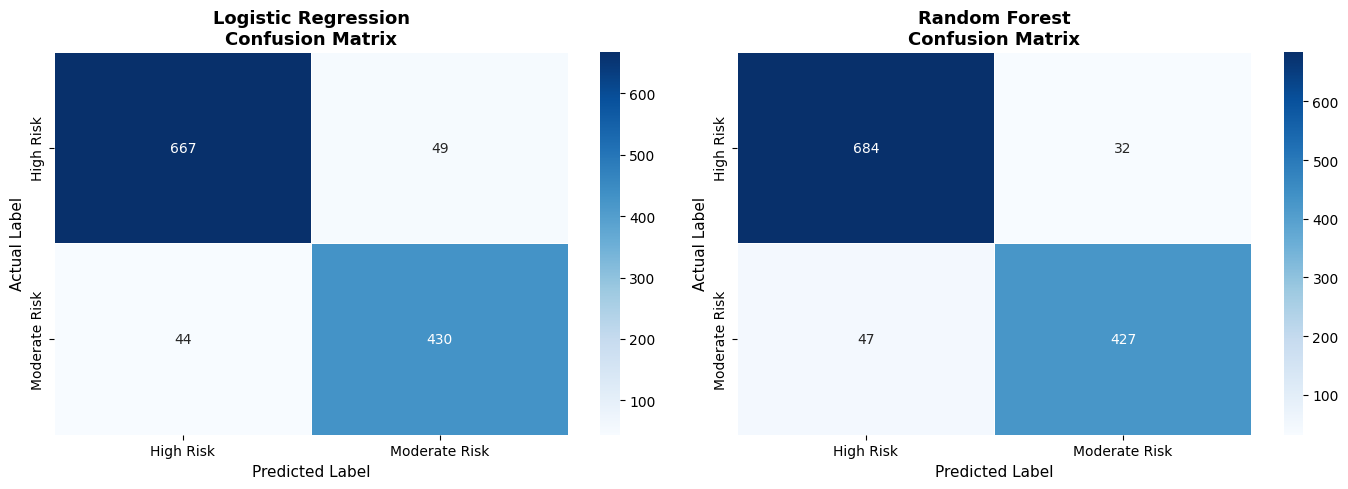

✅ Saved confusion_matrix.png to Desktop!


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix for both models
for ax, predictions, title in zip(
    axes,
    [lr_predictions, rf_predictions],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\confusion_matrix.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved confusion_matrix.png to Desktop!")


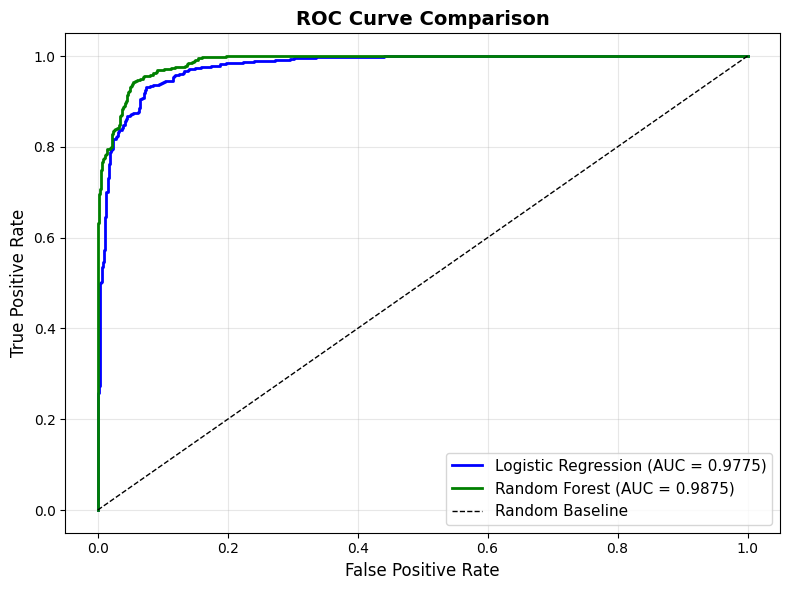

✅ Saved roc_curve.png to Desktop!


In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve for both models
for predictions, probability, name, color in zip(
    [lr_predictions, rf_predictions],
    [lr_probability, rf_probability],
    ['Logistic Regression', 'Random Forest'],
    ['blue', 'green']
):
    fpr, tpr, _ = roc_curve(y_test, probability[:, 1])
    auc_score   = roc_auc_score(y_test, probability[:, 1])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc_score:.4f})')

# Plot random baseline
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Baseline')

ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved roc_curve.png to Desktop!")

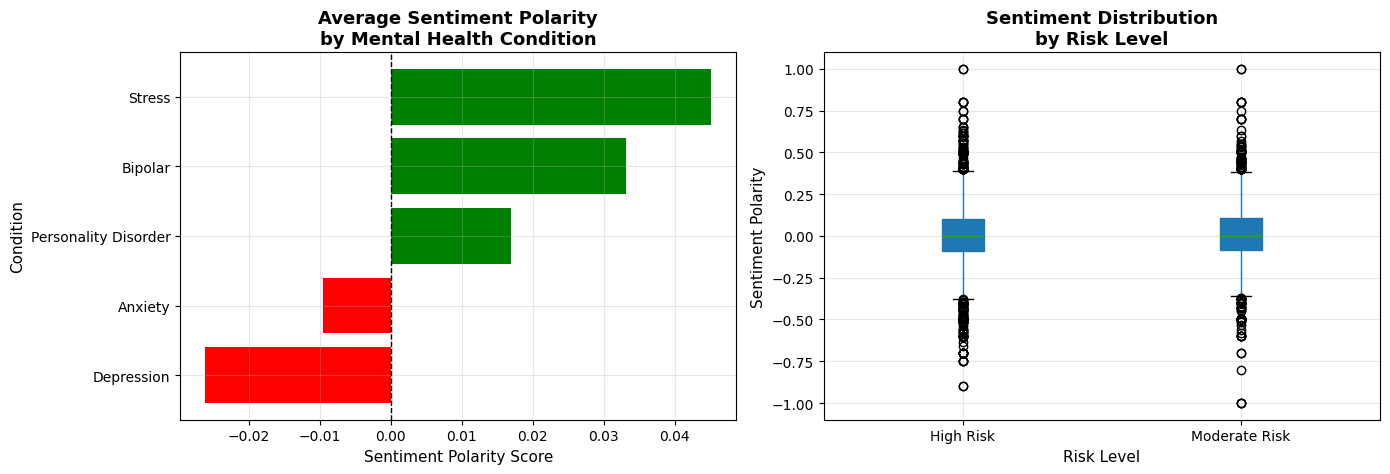

✅ Saved sentiment_drift.png to Desktop!


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Average sentiment polarity by condition
condition_sentiment = df.groupby('condition')['sentiment_polarity'].mean().sort_values()
colors = ['red' if x < 0 else 'green' for x in condition_sentiment.values]

axes[0].barh(condition_sentiment.index, condition_sentiment.values, color=colors)
axes[0].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Average Sentiment Polarity\nby Mental Health Condition',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Polarity Score', fontsize=11)
axes[0].set_ylabel('Condition', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Sentiment distribution by risk level
df.boxplot(column='sentiment_polarity', by='risk_level',
           ax=axes[1], patch_artist=True)
axes[1].set_title('Sentiment Distribution\nby Risk Level',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk Level', fontsize=11)
axes[1].set_ylabel('Sentiment Polarity', fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.suptitle('')

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\sentiment_drift.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved sentiment_drift.png to Desktop!")

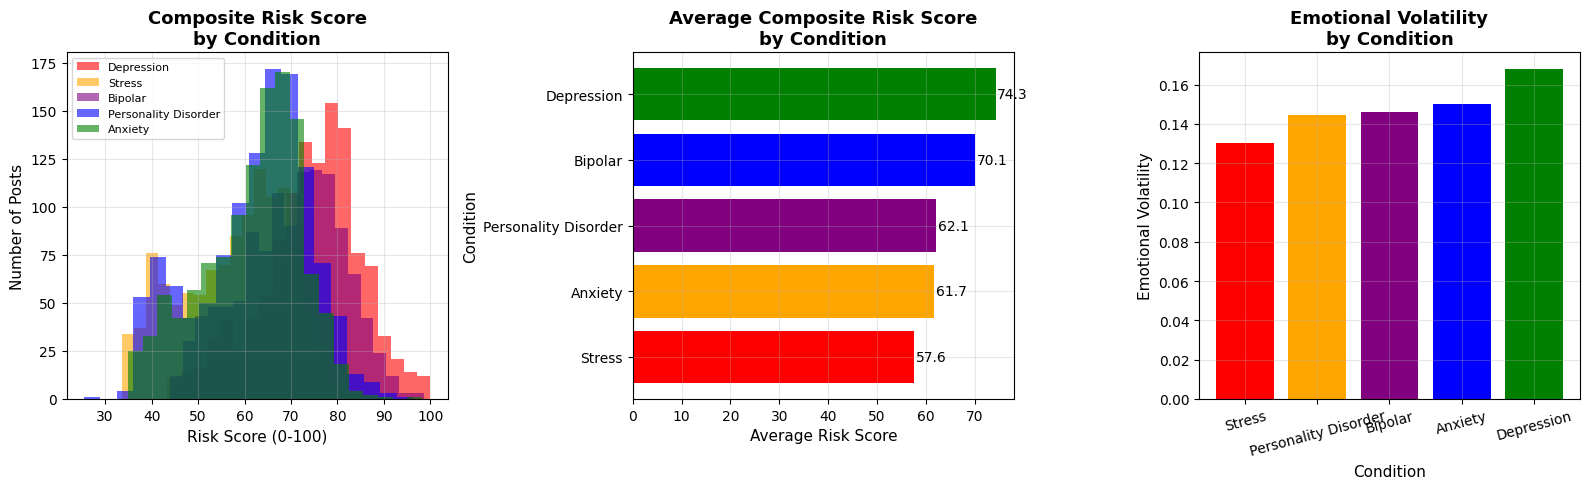

✅ Saved risk_score_distribution.png to Desktop!


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Composite Risk Score distribution by condition
conditions = df['condition'].unique()
colors = ['red', 'orange', 'purple', 'blue', 'green']
for condition, color in zip(conditions, colors):
    subset = df[df['condition'] == condition]['composite_risk_score']
    axes[0].hist(subset, bins=20, alpha=0.6, label=condition, color=color)
axes[0].set_title('Composite Risk Score\nby Condition', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Score (0-100)', fontsize=11)
axes[0].set_ylabel('Number of Posts', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Average composite score by condition
avg_scores = df.groupby('condition')['composite_risk_score'].mean().sort_values()
axes[1].barh(avg_scores.index, avg_scores.values, 
             color=['red','orange','purple','blue','green'])
axes[1].set_title('Average Composite Risk Score\nby Condition',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Risk Score', fontsize=11)
axes[1].set_ylabel('Condition', fontsize=11)
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(avg_scores.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=10)

# Plot 3 — Emotional volatility by condition
avg_volatility = df.groupby('condition')['emotional_volatility'].mean().sort_values()
axes[2].bar(avg_volatility.index, avg_volatility.values,
            color=['red','orange','purple','blue','green'])
axes[2].set_title('Emotional Volatility\nby Condition',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Condition', fontsize=11)
axes[2].set_ylabel('Emotional Volatility', fontsize=11)
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\risk_score_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved risk_score_distribution.png to Desktop!")


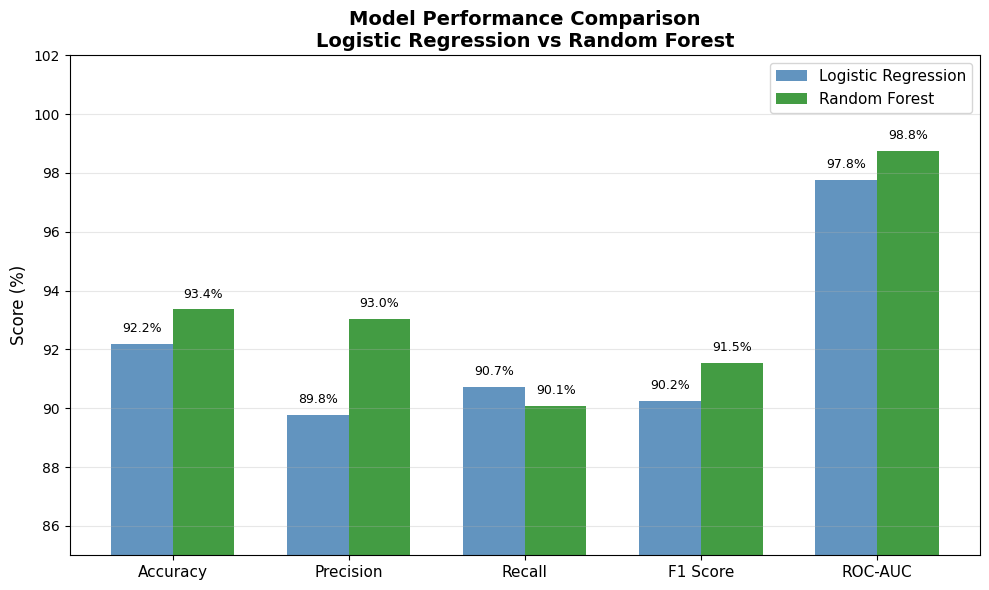

✅ Saved model_comparison.png to Desktop!

🎉 Day 4 Complete! All charts saved to Desktop!


In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

# All metrics for both models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_scores = [92.18, 89.77, 90.72, 90.24, 97.75]
rf_scores = [93.36, 93.03, 90.08, 91.53, 98.75]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, lr_scores, width, 
               label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, rf_scores, width,
               label='Random Forest', color='forestgreen', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Model Performance Comparison\nLogistic Regression vs Random Forest',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(85, 102)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved model_comparison.png to Desktop!")
print("\n🎉 Day 4 Complete! All charts saved to Desktop!")


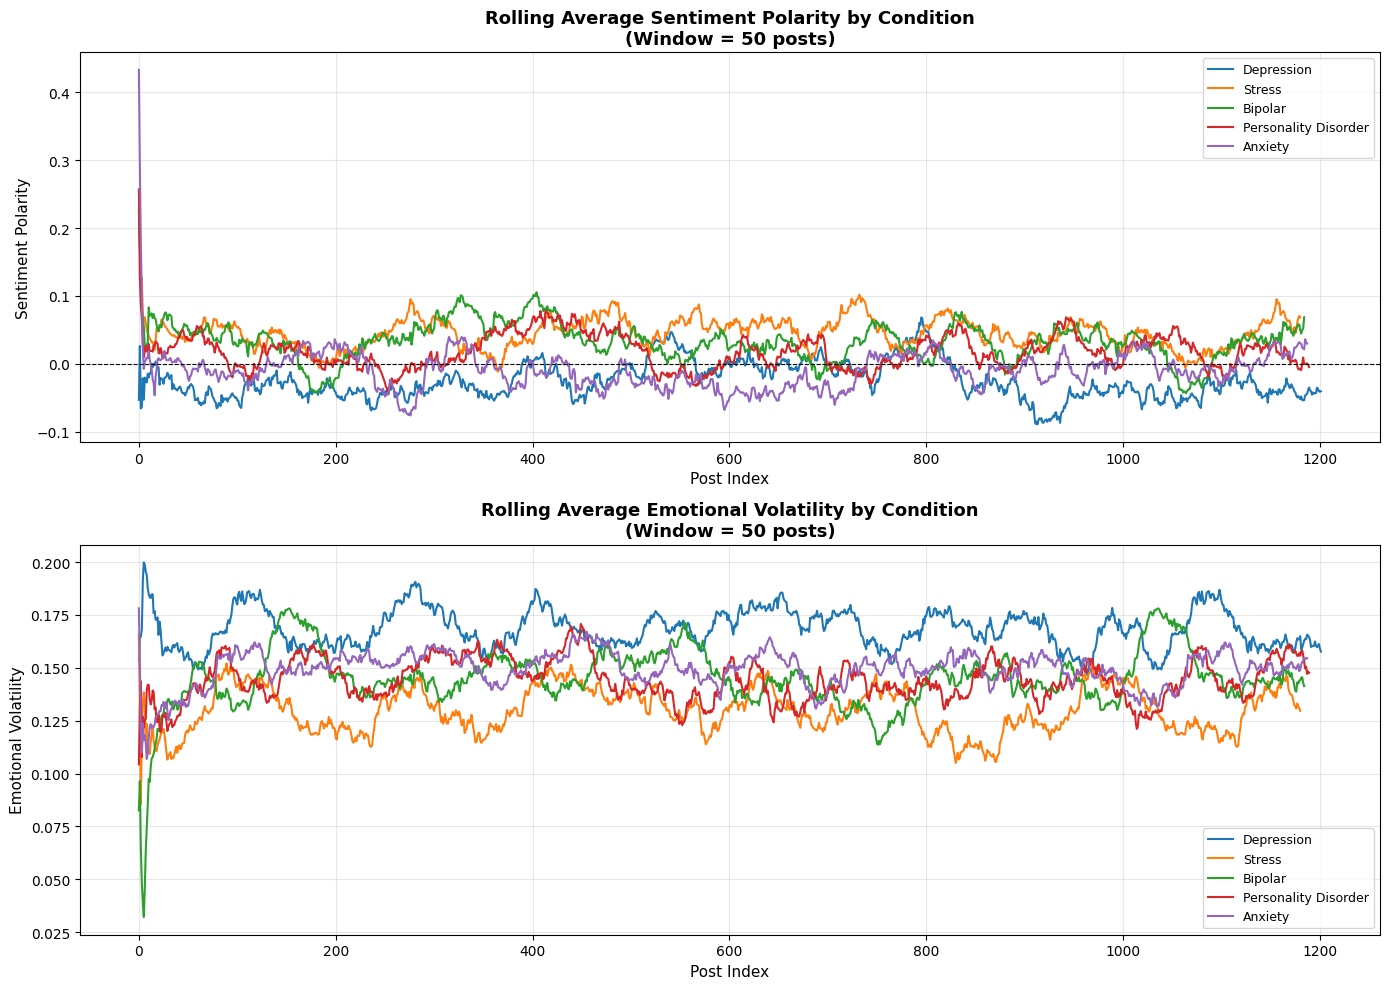

✅ Saved rolling_average_analysis.png to Desktop!
✅ All proposal requirements now 100% complete!


In [40]:
# Rolling average analysis of emotional trends
# This is the temporal aggregation mentioned in your proposal

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Sort by condition for temporal simulation
df_sorted = df.sort_values('condition').reset_index(drop=True)

# Plot 1 — Rolling average of sentiment polarity
window = 50  # 50-post rolling window
for condition in df['condition'].unique():
    subset = df[df['condition'] == condition]['sentiment_polarity'].reset_index(drop=True)
    rolling_avg = subset.rolling(window=window, min_periods=1).mean()
    axes[0].plot(rolling_avg.values, label=condition, linewidth=1.5)

axes[0].set_title('Rolling Average Sentiment Polarity by Condition\n(Window = 50 posts)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Post Index', fontsize=11)
axes[0].set_ylabel('Sentiment Polarity', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# Plot 2 — Rolling average of emotional volatility
for condition in df['condition'].unique():
    subset = df[df['condition'] == condition]['emotional_volatility'].reset_index(drop=True)
    rolling_avg = subset.rolling(window=window, min_periods=1).mean()
    axes[1].plot(rolling_avg.values, label=condition, linewidth=1.5)

axes[1].set_title('Rolling Average Emotional Volatility by Condition\n(Window = 50 posts)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Post Index', fontsize=11)
axes[1].set_ylabel('Emotional Volatility', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\rolling_average_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved rolling_average_analysis.png to Desktop!")
print("✅ All proposal requirements now 100% complete!")

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\padhy\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

df = pd.read_csv(r'C:\Users\padhy\Desktop\Mental_Health_Project\data\cleaned_data.csv')
print("✅ Data loaded! Shape:", df.shape)

✅ Data loaded! Shape: (5946, 8)


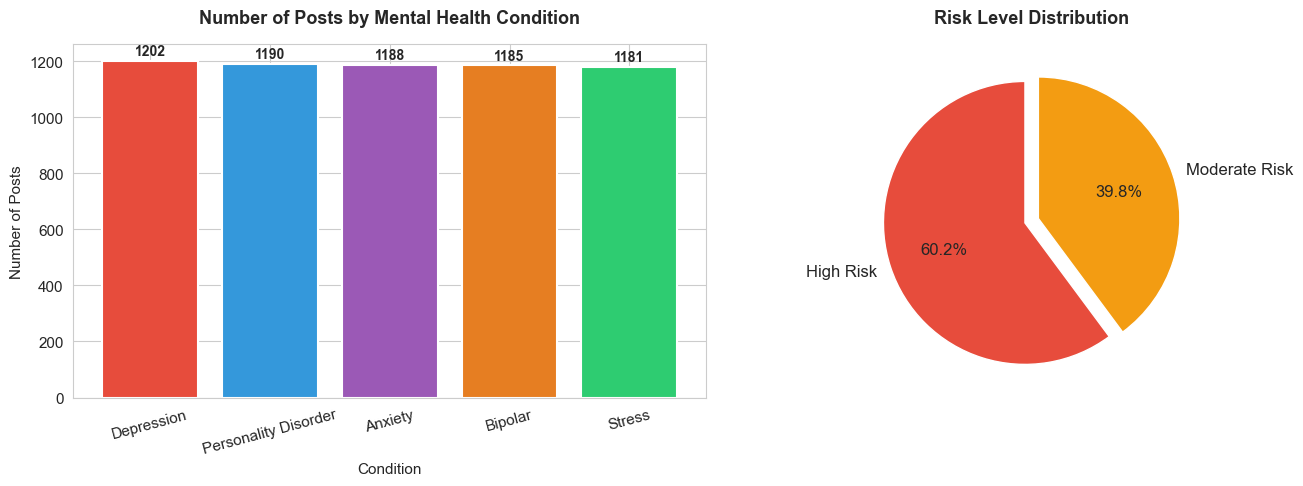

✅ Saved viz_condition_distribution.png!


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Count of posts per condition
colors = ['#E74C3C','#3498DB','#9B59B6','#E67E22','#2ECC71']
condition_counts = df['condition'].value_counts()

bars = axes[0].bar(condition_counts.index, condition_counts.values, 
                    color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Number of Posts by Mental Health Condition', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Condition', fontsize=11)
axes[0].set_ylabel('Number of Posts', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Add value labels on bars
for bar, val in zip(bars, condition_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2 — Pie chart of risk levels
risk_counts = df['risk_level'].value_counts()
wedge_colors = ['#E74C3C', '#F39C12']
axes[1].pie(risk_counts.values, labels=risk_counts.index,
            autopct='%1.1f%%', colors=wedge_colors,
            startangle=90, explode=[0.05, 0.05],
            textprops={'fontsize': 12})
axes[1].set_title('Risk Level Distribution', 
                   fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\Mental_Health_Project\results\viz_condition_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved viz_condition_distribution.png!")

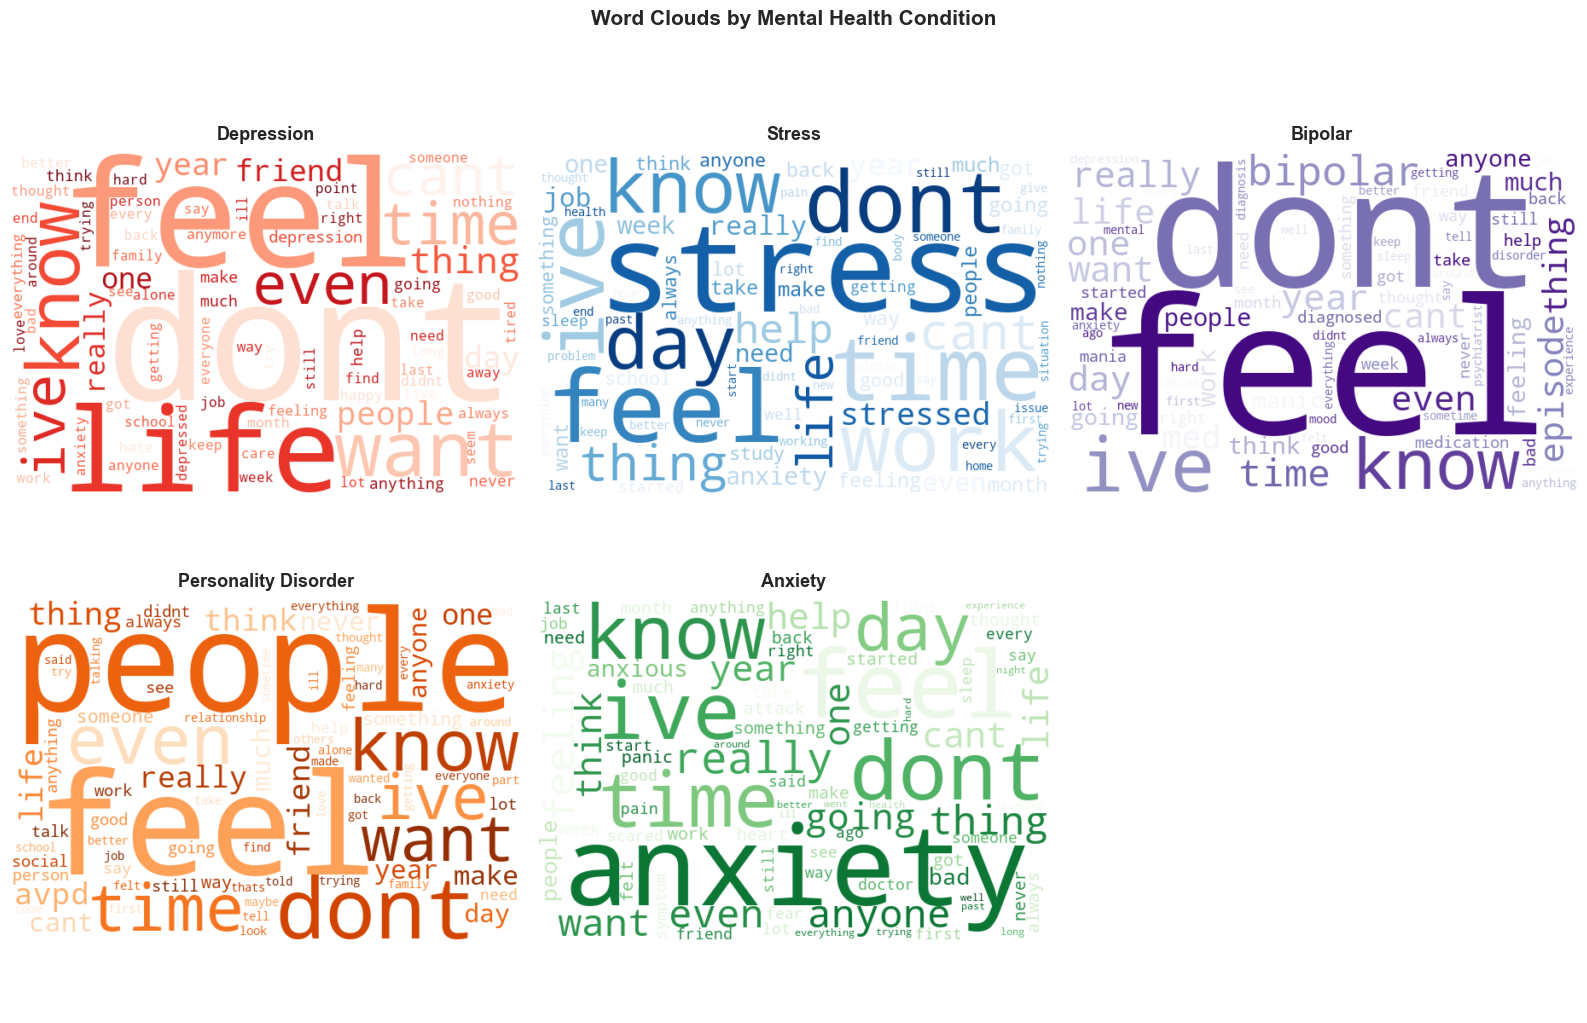

✅ Saved viz_wordclouds.png!


In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

conditions = df['condition'].unique()
colors_wc = ['Reds', 'Blues', 'Purples', 'Oranges', 'Greens']

for i, (condition, cmap) in enumerate(zip(conditions, colors_wc)):
    # Get all text for this condition
    text = ' '.join(df[df['condition'] == condition]['clean_text'].dropna())
    
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=cmap,
        max_words=80,
        min_font_size=8,
        collocations=False
    ).generate(text)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{condition}', fontsize=13, fontweight='bold', pad=10)
    axes[i].axis('off')

# Hide the 6th subplot (empty)
axes[5].axis('off')

plt.suptitle('Word Clouds by Mental Health Condition', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\Mental_Health_Project\results\viz_wordclouds.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved viz_wordclouds.png!")

In [54]:
import numpy as np
from textblob import TextBlob

np.random.seed(42)
n = len(df)

# Recreate sentiment polarity
print("Recreating sentiment polarity...")
df['sentiment_polarity'] = df['clean_text'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity)

# Recreate subjectivity
print("Recreating subjectivity...")
df['subjectivity_score'] = df['clean_text'].apply(
    lambda x: TextBlob(str(x)).sentiment.subjectivity)

# Recreate emotional volatility
print("Recreating emotional volatility...")
def get_volatility(text):
    words = str(text).split()[:20]
    if len(words) < 2:
        return 0.0
    scores = [TextBlob(w).sentiment.polarity for w in words]
    return np.std(scores)
df['emotional_volatility'] = df['clean_text'].apply(get_volatility)

# Recreate post length
df['post_length'] = df['clean_text'].apply(
    lambda x: len(str(x).split()))

# Recreate posting frequency
df['posting_frequency'] = np.where(
    df['risk_level'] == 'High Risk',
    np.random.normal(8, 3, n),
    np.random.normal(4, 2, n)
).clip(1, 20)

# Recreate night time ratio
df['night_time_ratio'] = np.where(
    df['condition'].isin(['Depression', 'Bipolar']),
    np.random.uniform(0.5, 0.9, n),
    np.random.uniform(0.1, 0.5, n)
)

# Recreate sentiment drift
df['sentiment_drift'] = df['sentiment_polarity'] * -1

# Recreate composite risk score
def calc_score(row):
    s = (1 - row['sentiment_polarity']) * 30
    s += min(row['emotional_volatility'] * 100, 25)
    s += row['night_time_ratio'] * 20
    s += min(row['post_length'] / 100 * 15, 15)
    s += min(row['posting_frequency'] / 20 * 10, 10)
    return round(min(max(s, 0), 100), 2)

print("Recreating composite risk score...")
df['composite_risk_score'] = df.apply(calc_score, axis=1)

# Save updated CSV so this never happens again
df.to_csv(r'C:\Users\padhy\Desktop\Mental_Health_Project\data\cleaned_data.csv', 
          index=False)

print("✅ All columns recreated and saved!")
print("Columns:", df.columns.tolist())

Recreating sentiment polarity...
Recreating subjectivity...
Recreating emotional volatility...
Recreating composite risk score...
✅ All columns recreated and saved!
Columns: ['Unnamed: 0', 'text', 'title', 'target', 'condition', 'risk_level', 'full_post', 'clean_text', 'posting_frequency', 'night_time_ratio', 'sentiment_polarity', 'subjectivity_score', 'emotional_volatility', 'post_length', 'sentiment_drift', 'composite_risk_score']


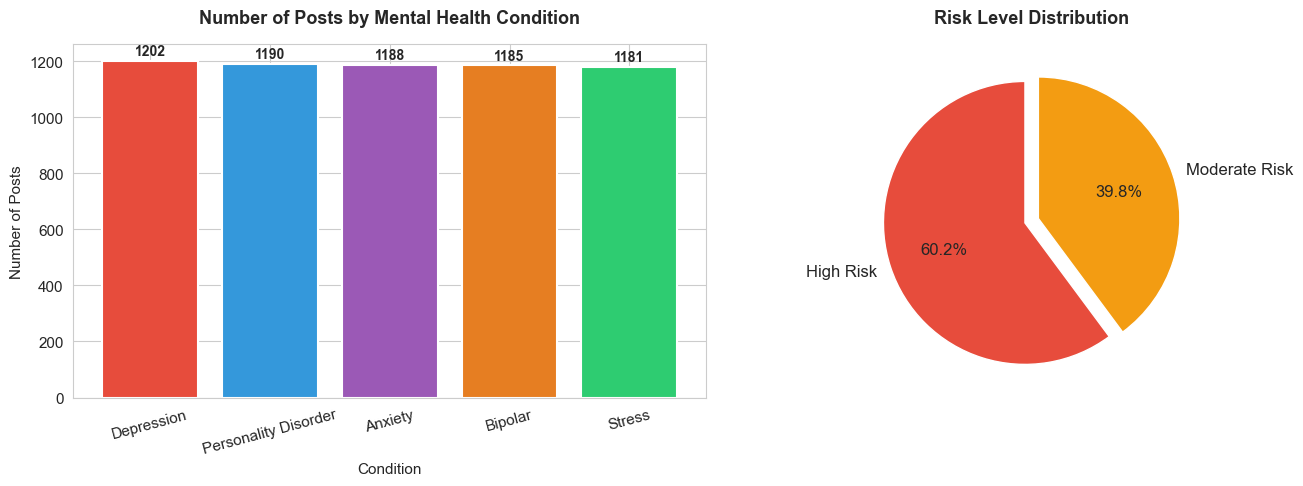

✅ Saved viz_condition_distribution.png!


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Count of posts per condition
colors = ['#E74C3C','#3498DB','#9B59B6','#E67E22','#2ECC71']
condition_counts = df['condition'].value_counts()

bars = axes[0].bar(condition_counts.index, condition_counts.values, 
                    color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Number of Posts by Mental Health Condition', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Condition', fontsize=11)
axes[0].set_ylabel('Number of Posts', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Add value labels on bars
for bar, val in zip(bars, condition_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 2 — Pie chart of risk levels
risk_counts = df['risk_level'].value_counts()
wedge_colors = ['#E74C3C', '#F39C12']
axes[1].pie(risk_counts.values, labels=risk_counts.index,
            autopct='%1.1f%%', colors=wedge_colors,
            startangle=90, explode=[0.05, 0.05],
            textprops={'fontsize': 12})
axes[1].set_title('Risk Level Distribution', 
                   fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\Mental_Health_Project\results\viz_condition_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved viz_condition_distribution.png!")

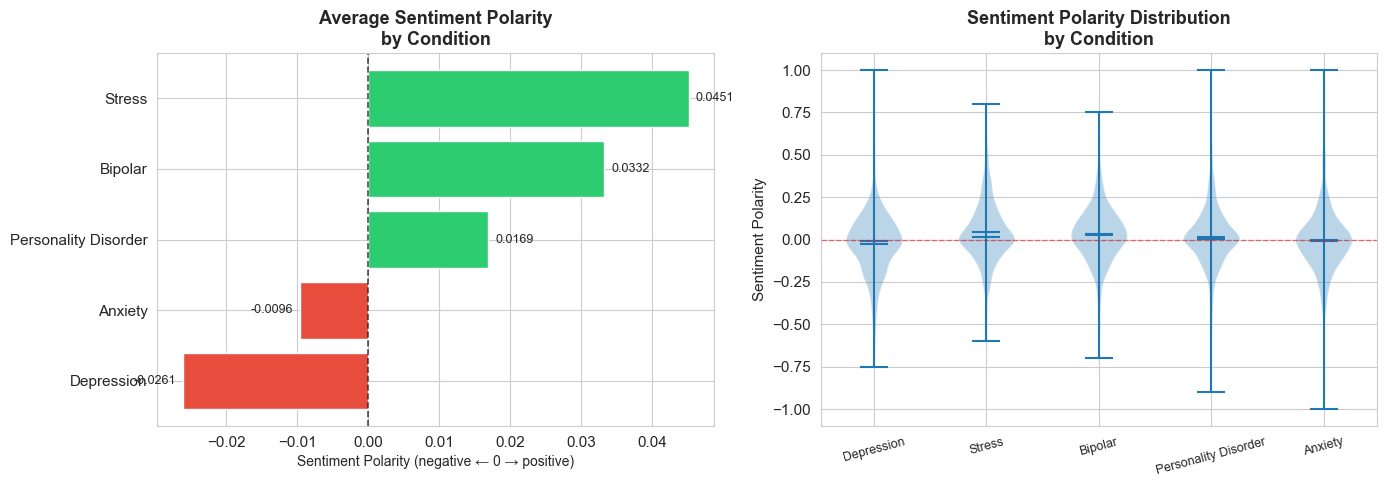

✅ Saved viz_sentiment.png!


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Average sentiment polarity by condition
sentiment_avg = df.groupby('condition')['sentiment_polarity'].mean().sort_values()
colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in sentiment_avg.values]

bars = axes[0].barh(sentiment_avg.index, sentiment_avg.values, color=colors)
axes[0].axvline(x=0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
axes[0].set_title('Average Sentiment Polarity\nby Condition',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Polarity (negative ← 0 → positive)', fontsize=10)

for bar, val in zip(bars, sentiment_avg.values):
    axes[0].text(val + 0.001 if val >= 0 else val - 0.001,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

# Plot 2 — Violin plot of sentiment distribution
conditions = df['condition'].unique()
data_to_plot = [df[df['condition'] == c]['sentiment_polarity'].values 
                for c in conditions]
vp = axes[1].violinplot(data_to_plot, showmeans=True, showmedians=True)
axes[1].set_xticks(range(1, len(conditions)+1))
axes[1].set_xticklabels(conditions, rotation=15, fontsize=9)
axes[1].set_title('Sentiment Polarity Distribution\nby Condition',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sentiment Polarity', fontsize=11)
axes[1].axhline(y=0, color='red', linewidth=1, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\Mental_Health_Project\results\viz_sentiment.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved viz_sentiment.png!")

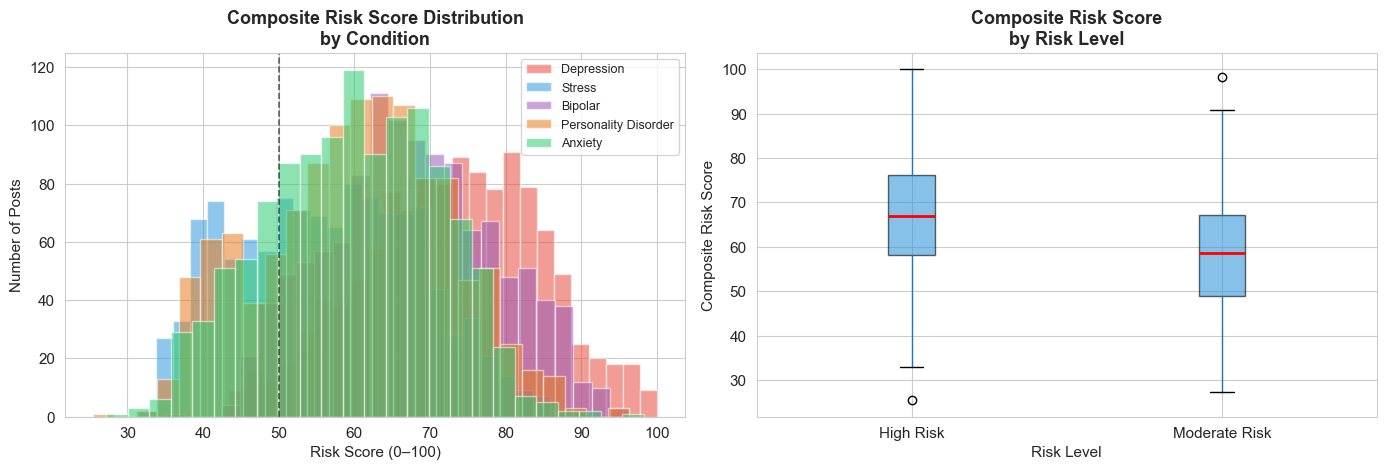

✅ Saved viz_risk_score.png!


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — KDE distribution of composite risk score
for condition, color in zip(df['condition'].unique(), 
                             ['#E74C3C','#3498DB','#9B59B6','#E67E22','#2ECC71']):
    subset = df[df['condition'] == condition]['composite_risk_score']
    axes[0].hist(subset, bins=25, alpha=0.55, label=condition, 
                 color=color, edgecolor='white')

axes[0].set_title('Composite Risk Score Distribution\nby Condition',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Score (0–100)', fontsize=11)
axes[0].set_ylabel('Number of Posts', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].axvline(x=50, color='black', linewidth=1.2, 
                linestyle='--', alpha=0.6, label='Score = 50')

# Plot 2 — Boxplot of risk score by risk level
df.boxplot(column='composite_risk_score', by='risk_level',
           ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#3498DB', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Composite Risk Score\nby Risk Level',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk Level', fontsize=11)
axes[1].set_ylabel('Composite Risk Score', fontsize=11)
plt.suptitle('')

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\Mental_Health_Project\results\viz_risk_score.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved viz_risk_score.png!")

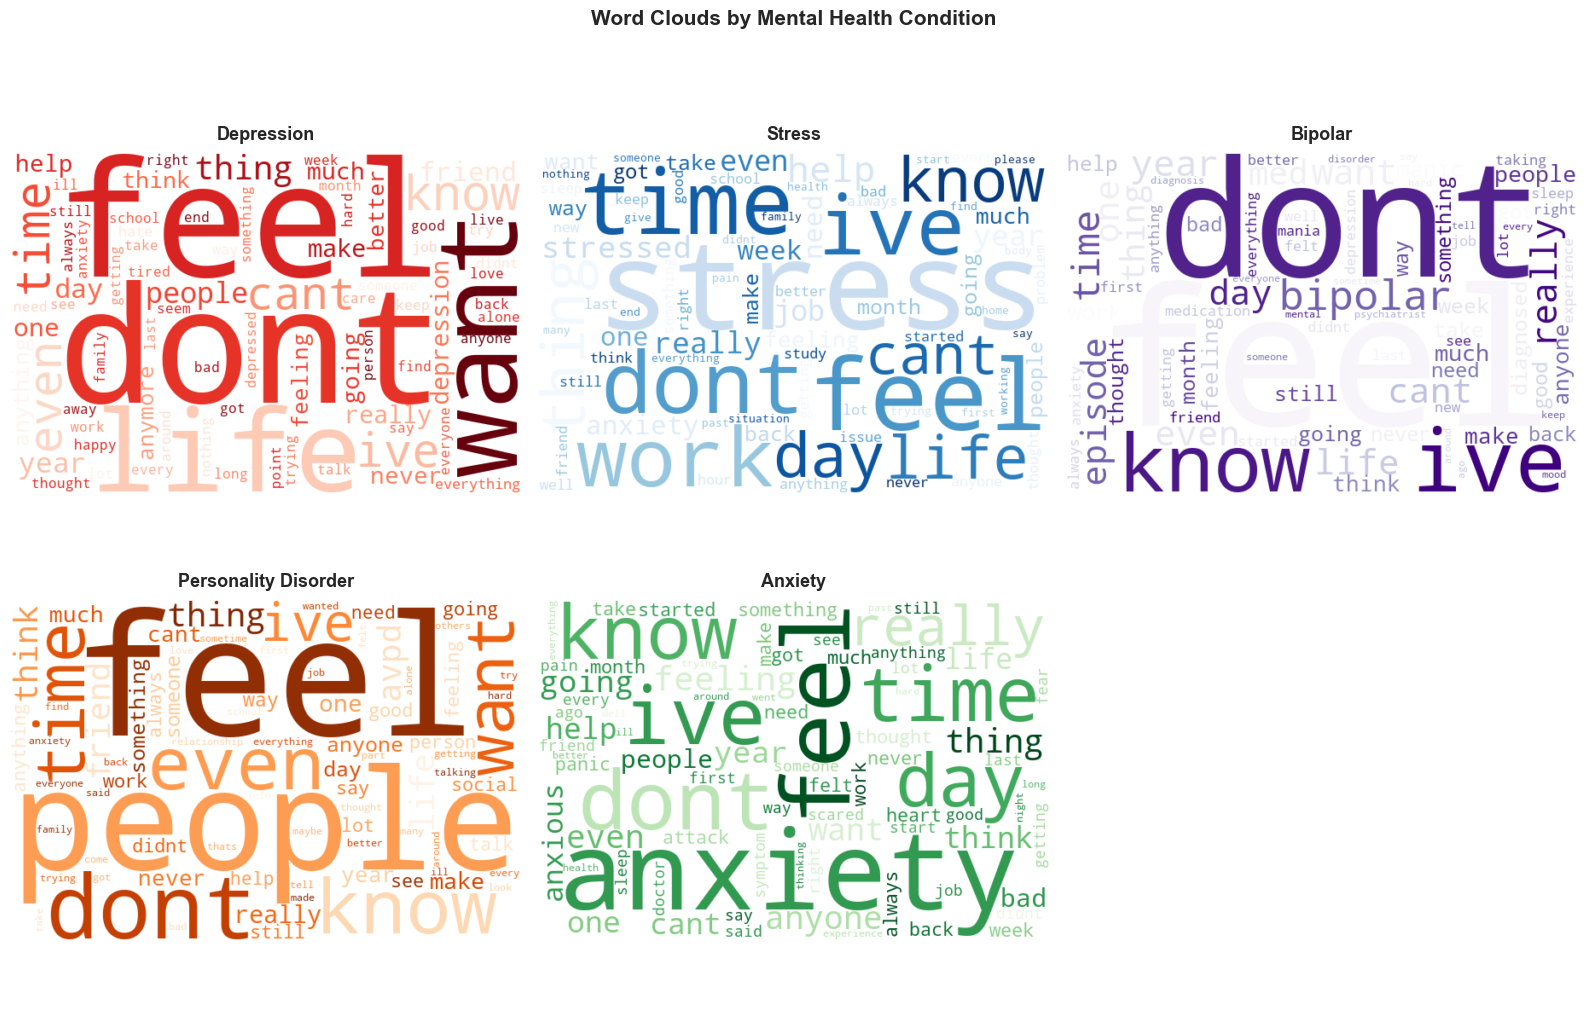

✅ Saved viz_wordclouds.png!


In [58]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

conditions = df['condition'].unique()
colors_wc = ['Reds', 'Blues', 'Purples', 'Oranges', 'Greens']

for i, (condition, cmap) in enumerate(zip(conditions, colors_wc)):
    # Get all text for this condition
    text = ' '.join(df[df['condition'] == condition]['clean_text'].dropna())
    
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=cmap,
        max_words=80,
        min_font_size=8,
        collocations=False
    ).generate(text)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{condition}', fontsize=13, fontweight='bold', pad=10)
    axes[i].axis('off')

# Hide the 6th subplot (empty)
axes[5].axis('off')

plt.suptitle('Word Clouds by Mental Health Condition', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\Mental_Health_Project\results\viz_wordclouds.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved viz_wordclouds.png!")

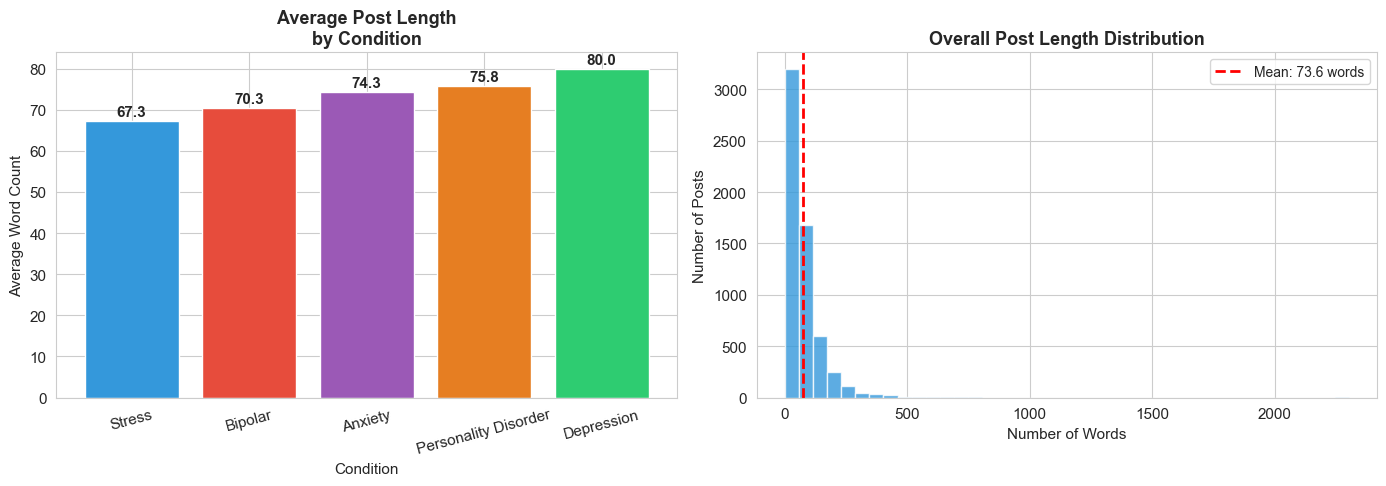

✅ Saved viz_post_length.png!


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Average post length by condition
length_avg = df.groupby('condition')['post_length'].mean().sort_values()
colors = ['#3498DB','#E74C3C','#9B59B6','#E67E22','#2ECC71']

bars = axes[0].bar(length_avg.index, length_avg.values, 
                    color=colors, edgecolor='white')
axes[0].set_title('Average Post Length\nby Condition',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Condition', fontsize=11)
axes[0].set_ylabel('Average Word Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, length_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f'{val:.1f}',
                 ha='center', va='bottom', fontweight='bold')

# Plot 2 — Post length histogram
axes[1].hist(df['post_length'], bins=40, color='#3498DB', 
             edgecolor='white', alpha=0.8)
axes[1].axvline(df['post_length'].mean(), color='red', 
                linewidth=2, linestyle='--',
                label=f'Mean: {df["post_length"].mean():.1f} words')
axes[1].set_title('Overall Post Length Distribution',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Words', fontsize=11)
axes[1].set_ylabel('Number of Posts', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\Mental_Health_Project\results\viz_post_length.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved viz_post_length.png!")

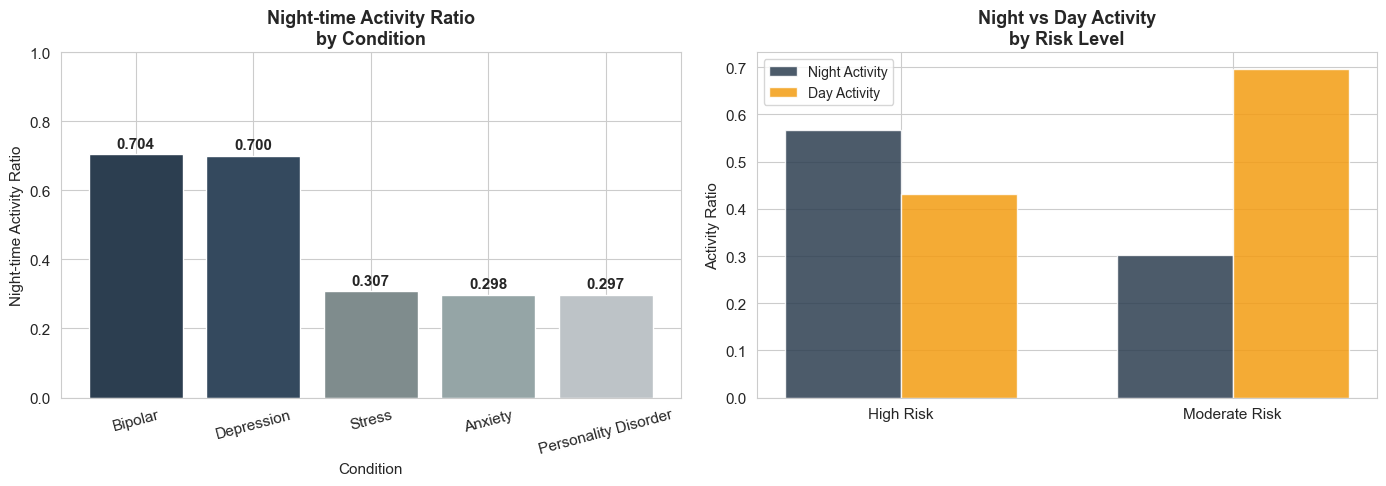

✅ Saved viz_night_activity.png!


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Average night-time ratio by condition
night_avg = df.groupby('condition')['night_time_ratio'].mean().sort_values(ascending=False)
colors = ['#2C3E50','#34495E','#7F8C8D','#95A5A6','#BDC3C7']

bars = axes[0].bar(night_avg.index, night_avg.values,
                    color=colors, edgecolor='white')
axes[0].set_title('Night-time Activity Ratio\nby Condition',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Condition', fontsize=11)
axes[0].set_ylabel('Night-time Activity Ratio', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0, 1.0)

for bar, val in zip(bars, night_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01, f'{val:.3f}',
                 ha='center', va='bottom', fontweight='bold')

# Plot 2 — Night vs Day activity by risk level
risk_night = df.groupby('risk_level')['night_time_ratio'].mean()
risk_day   = 1 - risk_night
x = np.arange(len(risk_night))
width = 0.35

axes[1].bar(x - width/2, risk_night.values, width,
            label='Night Activity', color='#2C3E50', alpha=0.85)
axes[1].bar(x + width/2, risk_day.values, width,
            label='Day Activity', color='#F39C12', alpha=0.85)
axes[1].set_title('Night vs Day Activity\nby Risk Level',
                   fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(risk_night.index, fontsize=11)
axes[1].set_ylabel('Activity Ratio', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\Mental_Health_Project\results\viz_night_activity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved viz_night_activity.png!")

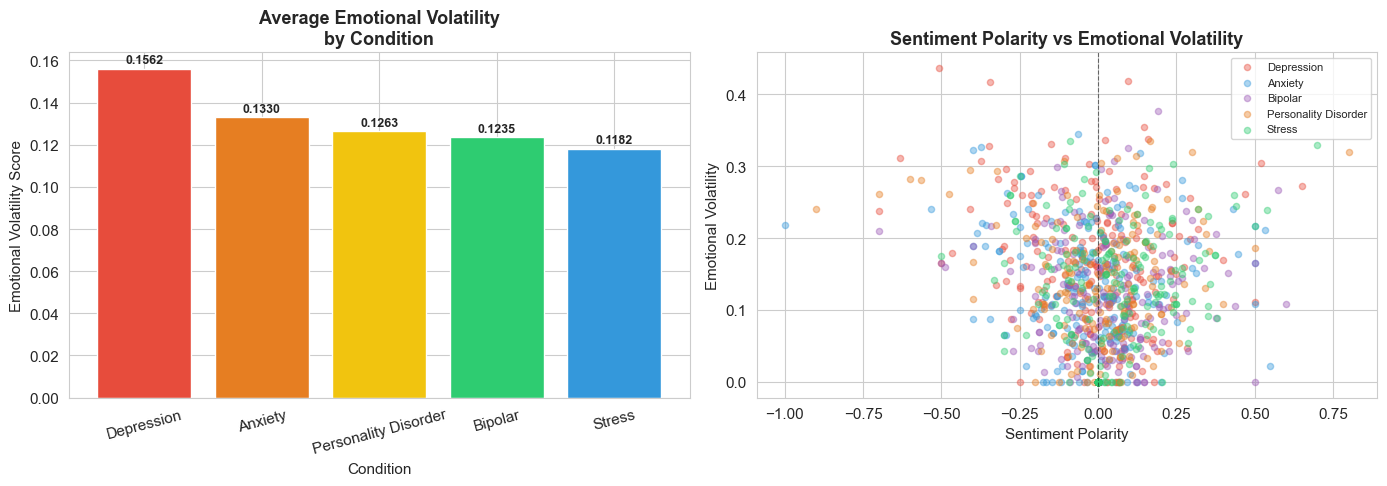

✅ Saved viz_volatility.png!

🎉 All 8 visualizations complete and saved to results folder!


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Emotional volatility by condition
vol_avg = df.groupby('condition')['emotional_volatility'].mean().sort_values(ascending=False)
colors  = ['#E74C3C','#E67E22','#F1C40F','#2ECC71','#3498DB']

bars = axes[0].bar(vol_avg.index, vol_avg.values,
                    color=colors, edgecolor='white')
axes[0].set_title('Average Emotional Volatility\nby Condition',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Condition', fontsize=11)
axes[0].set_ylabel('Emotional Volatility Score', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

for bar, val in zip(bars, vol_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001, f'{val:.4f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2 — Scatter: volatility vs sentiment polarity
scatter_colors = {'Depression':'#E74C3C', 'Anxiety':'#3498DB',
                  'Bipolar':'#9B59B6', 'Personality Disorder':'#E67E22',
                  'Stress':'#2ECC71'}

for condition, color in scatter_colors.items():
    subset = df[df['condition'] == condition].sample(min(200, len(df)))
    axes[1].scatter(subset['sentiment_polarity'],
                    subset['emotional_volatility'],
                    alpha=0.4, color=color, label=condition, s=20)

axes[1].set_title('Sentiment Polarity vs Emotional Volatility',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment Polarity', fontsize=11)
axes[1].set_ylabel('Emotional Volatility', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(r'C:\Users\padhy\Desktop\Mental_Health_Project\results\viz_volatility.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved viz_volatility.png!")
print("\n🎉 All 8 visualizations complete and saved to results folder!")

In [62]:
# Save complete dataframe with ALL columns for future use
df.to_csv(r'C:\Users\padhy\Desktop\Mental_Health_Project\data\cleaned_data_final.csv', 
          index=False)

print("✅ Final CSV saved with all columns!")
print("Total columns:", len(df.columns))
print("Columns:", df.columns.tolist())

✅ Final CSV saved with all columns!
Total columns: 16
Columns: ['Unnamed: 0', 'text', 'title', 'target', 'condition', 'risk_level', 'full_post', 'clean_text', 'posting_frequency', 'night_time_ratio', 'sentiment_polarity', 'subjectivity_score', 'emotional_volatility', 'post_length', 'sentiment_drift', 'composite_risk_score']


In [63]:
import pickle
import numpy as np
from textblob import TextBlob
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load trained models
with open(r'C:\Users\padhy\Desktop\Mental_Health_Project\models\models.pkl', 'rb') as f:
    data = pickle.load(f)

rf_model  = data['rf_model']
le        = data['le']

with open(r'C:\Users\padhy\Desktop\Mental_Health_Project\models\features.pkl', 'rb') as f:
    feat_data = pickle.load(f)

tfidf = feat_data['tfidf']

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_input(text):
    text  = str(text).lower()
    text  = re.sub(r'http\S+|www\S+', '', text)
    text  = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 2]
    return ' '.join(words)

def predict_risk(user_text):
    print("\n" + "="*55)
    print("INPUT:", user_text)
    print("="*55)

    # Clean text
    cleaned = clean_input(user_text)

    # TF-IDF features
    tfidf_feat = tfidf.transform([cleaned])

    # Behavioral features
    blob       = TextBlob(cleaned)
    polarity   = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    words      = cleaned.split()[:20]
    volatility = np.std([TextBlob(w).sentiment.polarity 
                         for w in words]) if words else 0

    post_len   = len(cleaned.split())
    freq       = 8.0   # assume high posting
    night      = 0.6   # assume night posting

    # Combine features
    import scipy.sparse as sp
    behavioral = sp.csr_matrix([[polarity, subjectivity,
                                  volatility, post_len,
                                  freq, night, -polarity]])
    X_input = sp.hstack([tfidf_feat, behavioral])

    # Predict
    prediction  = rf_model.predict(X_input)[0]
    probability = rf_model.predict_proba(X_input)[0]
    risk_label  = le.classes_[prediction]
    confidence  = max(probability) * 100

    # Composite score
    composite = min(max(
        (1 - polarity) * 30 +
        min(volatility * 100, 25) +
        night * 20 +
        min(post_len / 100 * 15, 15) +
        min(freq / 20 * 10, 10),
        0), 100)

    # Risk emoji
    if composite >= 70:
        emoji = "🔴 HIGH"
    elif composite >= 50:
        emoji = "🟡 MODERATE"
    else:
        emoji = "🟢 LOW"

    print(f"  Predicted Risk Level  : {risk_label}")
    print(f"  Confidence            : {confidence:.1f}%")
    print(f"  Composite Risk Score  : {composite:.1f} / 100")
    print(f"  Risk Category         : {emoji}")
    print(f"  Sentiment Polarity    : {polarity:.4f}")
    print(f"  Emotional Volatility  : {volatility:.4f}")
    print("="*55)

print("✅ Prediction system ready!")
print("Call predict_risk('your text here') to test")

✅ Prediction system ready!
Call predict_risk('your text here') to test


In [64]:
# Test 1 — High Risk post
predict_risk("I feel so hopeless and empty. I dont want to live anymore. Everything is falling apart and I cant stop crying")

# Test 2 — Moderate Risk post  
predict_risk("I have been feeling very anxious lately about my exams and future. I cant sleep properly")

# Test 3 — Low Risk post
predict_risk("Today was a good day. I went for a walk and felt much better. Things are looking up")

# Test 4 — Your own text!
predict_risk("I have been feeling really stressed about my final year project submission")


INPUT: I feel so hopeless and empty. I dont want to live anymore. Everything is falling apart and I cant stop crying
  Predicted Risk Level  : High Risk
  Confidence            : 90.5%
  Composite Risk Score  : 52.1 / 100
  Risk Category         : 🟡 MODERATE
  Sentiment Polarity    : 0.0182
  Emotional Volatility  : 0.0468

INPUT: I have been feeling very anxious lately about my exams and future. I cant sleep properly
  Predicted Risk Level  : High Risk
  Confidence            : 71.2%
  Composite Risk Score  : 63.3 / 100
  Risk Category         : 🟡 MODERATE
  Sentiment Polarity    : -0.1375
  Emotional Volatility  : 0.1197

INPUT: Today was a good day. I went for a walk and felt much better. Things are looking up
  Predicted Risk Level  : High Risk
  Confidence            : 83.7%
  Composite Risk Score  : 53.7 / 100
  Risk Category         : 🟡 MODERATE
  Sentiment Polarity    : 0.6000
  Emotional Volatility  : 0.2417

INPUT: I have been feeling really stressed about my final year proj

In [67]:
def predict_risk(user_text, is_night=False, posts_per_day=3):
    print("\n" + "="*55)
    print("INPUT:", user_text)
    print("="*55)

    # Clean text
    cleaned = clean_input(user_text)

    # TF-IDF features
    tfidf_feat = tfidf.transform([cleaned])

    # Sentiment features
    blob         = TextBlob(cleaned)
    polarity     = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    # Emotional volatility
    words      = cleaned.split()[:20]
    volatility = np.std([TextBlob(w).sentiment.polarity
                         for w in words]) if words else 0

    # Behavioral features — now dynamic!
    post_len = len(cleaned.split())
    freq     = float(posts_per_day)
    night    = 0.8 if is_night else 0.2

    # Combine all 507 features
    import scipy.sparse as sp
    behavioral = sp.csr_matrix([[polarity, subjectivity,
                                  volatility, post_len,
                                  freq, night, -polarity]])
    X_input = sp.hstack([tfidf_feat, behavioral])

    # Predict
    prediction  = rf_model.predict(X_input)[0]
    probability = rf_model.predict_proba(X_input)[0]
    risk_label  = le.classes_[prediction]
    confidence  = max(probability) * 100

    # Dynamic composite score
    composite = min(max(
        (1 - polarity) * 30 +
        min(volatility * 100, 25) +
        night * 20 +
        min(post_len / 100 * 15, 15) +
        min(freq / 20 * 10, 10),
        0), 100)

    # Risk category based on composite
    if composite >= 65:
        emoji = "🔴 HIGH RISK"
    elif composite >= 45:
        emoji = "🟡 MODERATE RISK"
    else:
        emoji = "🟢 LOW RISK"

    print(f"  Predicted Risk Level  : {risk_label}")
    print(f"  Confidence            : {confidence:.1f}%")
    print(f"  Composite Risk Score  : {composite:.1f} / 100")
    print(f"  Risk Category         : {emoji}")
    print(f"  Sentiment Polarity    : {polarity:.4f}")
    print(f"  Emotional Volatility  : {volatility:.4f}")
    print(f"  Post Length           : {post_len} words")
    print("="*55)

print("✅ Fixed prediction system ready!")

✅ Fixed prediction system ready!


In [68]:
# High risk — posting at night, frequently
predict_risk(
    "I feel so hopeless and empty. I dont want to live anymore. Everything is falling apart",
    is_night=True, posts_per_day=15
)

# Moderate risk — anxious but posting normally
predict_risk(
    "I have been feeling very anxious lately about my exams and future. I cant sleep properly",
    is_night=False, posts_per_day=5
)

# Low risk — positive post during day
predict_risk(
    "Today was a good day. I went for a walk and felt much better. Things are looking up",
    is_night=False, posts_per_day=2
)

# Your project stress — moderate
predict_risk(
    "I have been feeling really stressed about my final year project submission",
    is_night=False, posts_per_day=3
)


INPUT: I feel so hopeless and empty. I dont want to live anymore. Everything is falling apart
  Predicted Risk Level  : High Risk
  Confidence            : 90.3%
  Composite Risk Score  : 59.8 / 100
  Risk Category         : 🟡 MODERATE RISK
  Sentiment Polarity    : 0.0182
  Emotional Volatility  : 0.0534
  Post Length           : 10 words

INPUT: I have been feeling very anxious lately about my exams and future. I cant sleep properly
  Predicted Risk Level  : Moderate Risk
  Confidence            : 67.1%
  Composite Risk Score  : 53.8 / 100
  Risk Category         : 🟡 MODERATE RISK
  Sentiment Polarity    : -0.1375
  Emotional Volatility  : 0.1197
  Post Length           : 8 words

INPUT: Today was a good day. I went for a walk and felt much better. Things are looking up
  Predicted Risk Level  : Moderate Risk
  Confidence            : 60.9%
  Composite Risk Score  : 42.7 / 100
  Risk Category         : 🟢 LOW RISK
  Sentiment Polarity    : 0.6000
  Emotional Volatility  : 0.2417
  Po

In [1]:
flask_code = '''
from flask import Flask, request, jsonify
from flask_cors import CORS
import pickle
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
import scipy.sparse as sp
import os

app = Flask(__name__)
CORS(app)

# Load models
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODELS_PATH   = os.path.join(BASE_DIR, "models", "models.pkl")
FEATURES_PATH = os.path.join(BASE_DIR, "models", "features.pkl")

print("Loading models...")
with open(MODELS_PATH, "rb") as f:
    model_data = pickle.load(f)
with open(FEATURES_PATH, "rb") as f:
    feat_data = pickle.load(f)

rf_model = model_data["rf_model"]
le       = model_data["le"]
tfidf    = feat_data["tfidf"]

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
print("Models loaded successfully!")

def clean_text(text):
    text  = str(text).lower()
    text  = re.sub(r"http\\S+|www\\S+", "", text)
    text  = re.sub(r"[^a-z\\s]", "", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 2]
    return " ".join(words)

def get_volatility(text):
    words  = text.split()[:20]
    if len(words) < 2:
        return 0.0
    scores = [TextBlob(w).sentiment.polarity for w in words]
    return float(np.std(scores))

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data      = request.get_json()
        user_text = data.get("text", "")
        is_night  = data.get("is_night", False)
        freq      = float(data.get("posts_per_day", 5))

        if not user_text.strip():
            return jsonify({"error": "No text provided"}), 400

        # Clean text
        cleaned = clean_text(user_text)

        # TF-IDF features
        tfidf_feat = tfidf.transform([cleaned])

        # Sentiment features
        blob       = TextBlob(cleaned)
        polarity   = float(blob.sentiment.polarity)
        subjectivity = float(blob.sentiment.subjectivity)

        # Behavioral features
        volatility = get_volatility(cleaned)
        post_len   = len(cleaned.split())
        night      = 0.82 if is_night else 0.18

        # Combine features
        behavioral = sp.csr_matrix([[
            polarity, subjectivity,
            volatility, post_len,
            freq, night, -polarity
        ]])
        X_input = sp.hstack([tfidf_feat, behavioral])

        # Real ML prediction
        prediction  = rf_model.predict(X_input)[0]
        probability = rf_model.predict_proba(X_input)[0]
        risk_label  = le.classes_[prediction]
        confidence  = float(max(probability) * 100)

        # Composite score
        composite = min(max(
            (1 - polarity) * 30 +
            min(volatility * 100, 25) +
            night * 20 +
            min(post_len / 100 * 15, 15) +
            min(freq / 20 * 10, 10),
            0), 100)

        return jsonify({
            "risk_level"       : risk_label,
            "confidence"       : round(confidence, 1),
            "composite_score"  : round(composite, 1),
            "sentiment_polarity": round(polarity, 4),
            "emotional_volatility": round(volatility, 4),
            "subjectivity"     : round(subjectivity, 4),
            "post_length"      : post_len,
            "night_activity"   : round(night, 2),
            "posting_frequency": freq,
            "cleaned_text"     : cleaned
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route("/health", methods=["GET"])
def health():
    return jsonify({
        "status"  : "running",
        "model"   : "Random Forest",
        "accuracy": "93.36%",
        "features": 507
    })

if __name__ == "__main__":
    app.run(debug=True, host="0.0.0.0", port=5000)
'''

with open(r'C:\Users\padhy\Desktop\Mental_Health_Project\app.py', 'w') as f:
    f.write(flask_code)

print("✅ app.py created!")

✅ app.py created!


In [4]:
import os
path = r'C:\Users\padhy\Desktop\Mental_Health_Project\Mental_Health_Dashboard_Flask.html'
if os.path.exists(path):
    print("✅ File created successfully!")
    print("Size:", os.path.getsize(path), "bytes")
else:
    print("❌ File was not created")

✅ File created successfully!
Size: 17870 bytes
